<a href="https://colab.research.google.com/github/gabiuxo/Algoritmos-de-Aprendizaje-Automatico/blob/main/Actividad_1_Preprocesamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 1 — Diagnóstico y preprocesamiento de datos

**Materia:** Algoritmos de aprendizaje automático  
**Estudiante:** Gabriel Elizondo Martinez  
**Fecha:** 15 de agosto de 2026

## Identificación del dataset

- **Nombre:** Student Performance Factors Dataset.
- **Autor:** Mosap Abdel-Ghany.
- **Fuente:** Kaggle.
- **Liga de acceso:** https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset
- **Fecha de consulta:** 15 de agosto de 2026.
- **Última actualización reportada en Kaggle:** 16 de octubre de 2025.
- **Vigencia:** al momento de esta actividad, la actualización tiene menos de tres años.

## Contexto y posible tarea predictiva

En esta actividad analicé un conjunto de datos formado por factores académicos, personales, familiares y escolares relacionados con el desempeño estudiantil. Cada registro representa a un estudiante y cada columna describe una característica, por ejemplo, sus horas de estudio, asistencia, acceso a recursos o motivación.

Consideré `Exam_Score` como una posible variable objetivo porque contiene un puntaje numérico. Por ello, en una etapa posterior podría plantear un problema de **regresión** para estimar el puntaje de examen a partir de las demás variables. Un modelo de este tipo podría utilizarse como primera herramienta exploratoria para detectar estudiantes que quizá necesiten apoyo académico. Sin embargo, no debería utilizarse para tomar decisiones reales sin validación adicional y una revisión de posibles sesgos.

> Para evitar descargar manualmente el dataset, lo cargaré directamente en el entorno temporal de Google Colab. La fuente original que reporto y cito es Kaggle.

## 1. Importación de librerías

In [1]:
# data handling and visualization
import os
import glob
import sys
import subprocess
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# notebook display
from IPython.display import display, Markdown

# reproducible preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")

## 2. Carga automática del dataset

Primero intento cargar una copia pública del CSV. Si esa dirección no responde, el código utiliza `kagglehub` como respaldo. El archivo queda únicamente en la sesión temporal de Colab, así que no necesito descargarlo manualmente en mi computadora.

In [2]:
# public mirror used only for automatic loading
DATA_URL = "https://raw.githubusercontent.com/hsmanik/Student_performance_factors/main/StudentPerformanceFactors.csv"
KAGGLE_DATASET = "mosapabdelghany/student-performance-factors-dataset"

try:
    df_raw = pd.read_csv(DATA_URL)
    load_method = "public csv mirror"
except Exception:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "kagglehub"],
        check=True
    )
    import kagglehub

    dataset_path = kagglehub.dataset_download(KAGGLE_DATASET)
    csv_files = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)
    if not csv_files:
        raise FileNotFoundError("No csv file was found in the Kaggle dataset.")
    df_raw = pd.read_csv(csv_files[0])
    load_method = "kagglehub fallback"

print(f"Método de carga: {load_method}")
print(f"Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
display(df_raw.head())

Método de carga: public csv mirror
Dimensiones: 6,607 filas × 20 columnas


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 3. Revisión inicial del dataset

In [3]:
initial_rows, initial_columns = df_raw.shape
initial_missing = int(df_raw.isna().sum().sum())
initial_duplicates = int(df_raw.duplicated().sum())

print(f"Número de filas: {initial_rows:,}")
print(f"Número de columnas: {initial_columns}")
print(f"Valores faltantes totales: {initial_missing}")
print(f"Registros duplicados: {initial_duplicates}")

print("\nNombres de las variables:")
print(df_raw.columns.tolist())

print("\nInformación de tipos de datos:")
df_raw.info()

Número de filas: 6,607
Número de columnas: 20
Valores faltantes totales: 235
Registros duplicados: 0

Nombres de las variables:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Información de tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   

In [4]:
initial_profile = pd.DataFrame({
    "Tipo_de_dato": df_raw.dtypes.astype(str),
    "Valores_faltantes": df_raw.isna().sum(),
    "Valores_unicos": df_raw.nunique(dropna=True)
})

display(initial_profile)

,Tipo_de_dato,Valores_faltantes,Valores_unicos
Hours_Studied,int64,0,41
Attendance,int64,0,41
Parental_Involvement,object,0,3
Access_to_Resources,object,0,3
Extracurricular_Activities,object,0,2
Sleep_Hours,int64,0,7
Previous_Scores,int64,0,51
Motivation_Level,object,0,3
Internet_Access,object,0,2
Tutoring_Sessions,int64,0,9


In [5]:
print("Estadísticas descriptivas de variables numéricas:")
display(df_raw.describe().T.round(2))

print("Estadísticas descriptivas de variables categóricas:")
display(df_raw.describe(include="object").T)

print("Muestra aleatoria de cinco registros:")
display(df_raw.sample(5, random_state=42))

Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.98,5.99,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.98,11.55,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.03,1.47,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.07,14.40,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.49,1.23,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.97,1.03,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.24,3.89,55.0,65.0,67.0,69.0,101.0


Estadísticas descriptivas de variables categóricas:


,count,unique,top,freq
Parental_Involvement,6607,3,Medium,3362
Access_to_Resources,6607,3,Medium,3319
Extracurricular_Activities,6607,2,Yes,3938
Motivation_Level,6607,3,Medium,3351
Internet_Access,6607,2,Yes,6108
Family_Income,6607,3,Low,2672
Teacher_Quality,6529,3,Medium,3925
School_Type,6607,2,Public,4598
Peer_Influence,6607,3,Positive,2638
Learning_Disabilities,6607,2,No,5912


Muestra aleatoria de cinco registros:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
743,20,71,Medium,Low,No,7,87,High,Yes,1,Medium,Medium,Public,Negative,5,No,High School,Near,Male,65
5551,22,71,Medium,Low,Yes,7,98,Low,Yes,2,Low,High,Public,Neutral,2,No,High School,Moderate,Female,65
3442,21,91,High,Medium,Yes,6,53,High,Yes,1,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Female,71
6571,12,91,Medium,Low,Yes,8,81,Low,Yes,0,Low,Low,Public,Positive,4,No,High School,Moderate,Male,64
4204,21,63,Low,High,Yes,8,95,Medium,Yes,2,High,Medium,Public,Neutral,5,No,High School,Near,Male,66


### Mi interpretación del estado inicial

Identifiqué **6,607 registros y 20 variables**. Los tipos de datos coinciden en general con el contenido: las medidas cuantitativas están almacenadas como enteros y las categorías como texto. Encontré valores faltantes únicamente en `Teacher_Quality`, `Parental_Education_Level` y `Distance_from_Home`. No encontré registros duplicados exactos.

El dataset tiene una estructura adecuada para continuar, pero todavía requiere estandarizar categorías, comprobar rangos, tratar los valores faltantes y transformar las variables a una representación numérica compatible con futuros algoritmos.

## 4. Diagnóstico de calidad

In [6]:
object_columns_raw = df_raw.select_dtypes(include="object").columns.tolist()
numeric_columns_raw = df_raw.select_dtypes(include=np.number).columns.tolist()

# detect leading or trailing whitespace
whitespace_cells = 0
for column in object_columns_raw:
    non_null = df_raw[column].dropna().astype(str)
    whitespace_cells += int((non_null != non_null.str.strip()).sum())

# detect constants and possible identifiers
constant_columns = [
    column for column in df_raw.columns
    if df_raw[column].nunique(dropna=False) <= 1
]
identifier_candidates = [
    column for column in df_raw.columns
    if "id" in column.lower() or df_raw[column].nunique(dropna=False) == len(df_raw)
]

# detect objects that are mostly numeric text
numeric_text_candidates = []
for column in object_columns_raw:
    converted_ratio = pd.to_numeric(df_raw[column], errors="coerce").notna().mean()
    if converted_ratio >= 0.90:
        numeric_text_candidates.append(column)

# detect iqr outliers
outlier_rows = []
for column in numeric_columns_raw:
    q1 = df_raw[column].quantile(0.25)
    q3 = df_raw[column].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    outlier_count = int(
        ((df_raw[column] < lower_limit) | (df_raw[column] > upper_limit)).sum()
    )
    outlier_rows.append({
        "Variable": column,
        "Limite_inferior_IQR": lower_limit,
        "Limite_superior_IQR": upper_limit,
        "Valores_atipicos": outlier_count
    })

outlier_table = pd.DataFrame(outlier_rows)
display(outlier_table.round(2))

,Variable,Limite_inferior_IQR,Limite_superior_IQR,Valores_atipicos
0,Hours_Studied,4.0,36.0,43
1,Attendance,40.0,120.0,0
2,Sleep_Hours,3.0,11.0,0
3,Previous_Scores,25.5,125.5,0
4,Tutoring_Sessions,-0.5,3.5,430
5,Physical_Activity,-1.0,7.0,0
6,Exam_Score,59.0,75.0,104


In [7]:
missing_evidence = ", ".join(
    f"{column}: {count}"
    for column, count in df_raw.isna().sum().items()
    if count > 0
)

quality_diagnosis = pd.DataFrame([
    {
        "Problema_detectado": "Valores faltantes",
        "Variable_afectada": "Teacher_Quality, Parental_Education_Level y Distance_from_Home",
        "Evidencia": missing_evidence,
        "Tratamiento_propuesto": "Imputar la categoría más frecuente dentro de un pipeline reproducible."
    },
    {
        "Problema_detectado": "Registros duplicados",
        "Variable_afectada": "Dataset completo",
        "Evidencia": f"{initial_duplicates} duplicados exactos",
        "Tratamiento_propuesto": "Ejecutar drop_duplicates y registrar cuántas filas cambian."
    },
    {
        "Problema_detectado": "Espacios adicionales o formato de categorías",
        "Variable_afectada": "Columnas categóricas",
        "Evidencia": f"{whitespace_cells} celdas con espacios externos; las categorías deben conservar un formato canónico",
        "Tratamiento_propuesto": "Eliminar espacios y unificar mayúsculas/minúsculas mediante diccionarios."
    },
    {
        "Problema_detectado": "Columnas numéricas almacenadas como texto",
        "Variable_afectada": "Ninguna",
        "Evidencia": f"Candidatas detectadas: {numeric_text_candidates or 'ninguna'}",
        "Tratamiento_propuesto": "Convertir explícitamente las columnas numéricas esperadas para validar los tipos."
    },
    {
        "Problema_detectado": "Valores atípicos por criterio IQR",
        "Variable_afectada": "Hours_Studied, Tutoring_Sessions y Exam_Score",
        "Evidencia": "El criterio IQR detecta observaciones alejadas de la distribución central.",
        "Tratamiento_propuesto": "No eliminarlos automáticamente; revisar si son posibles dentro de su contexto."
    },
    {
        "Problema_detectado": "Rango imposible asumido",
        "Variable_afectada": "Exam_Score",
        "Evidencia": f"{int((df_raw['Exam_Score'] > 100).sum())} registro con puntaje superior a 100",
        "Tratamiento_propuesto": "Asumir escala de 0 a 100 y eliminar únicamente los registros fuera de ese rango."
    },
    {
        "Problema_detectado": "Variables constantes",
        "Variable_afectada": "Ninguna",
        "Evidencia": f"Columnas constantes: {constant_columns or 'ninguna'}",
        "Tratamiento_propuesto": "No se requiere eliminación."
    },
    {
        "Problema_detectado": "Identificadores sin aporte predictivo",
        "Variable_afectada": "Ninguna",
        "Evidencia": f"Candidatas: {identifier_candidates or 'ninguna'}",
        "Tratamiento_propuesto": "No se requiere eliminación de identificadores."
    }
])

display(quality_diagnosis)

,Problema_detectado,Variable_afectada,Evidencia,Tratamiento_propuesto
0,Valores faltantes,"Teacher_Quality, Parental_Education_Level y Di...","Teacher_Quality: 78, Parental_Education_Level:...",Imputar la categoría más frecuente dentro de u...
1,Registros duplicados,Dataset completo,0 duplicados exactos,Ejecutar drop_duplicates y registrar cuántas f...
2,Espacios adicionales o formato de categorías,Columnas categóricas,0 celdas con espacios externos; las categorías...,Eliminar espacios y unificar mayúsculas/minúsc...
3,Columnas numéricas almacenadas como texto,Ninguna,Candidatas detectadas: ninguna,Convertir explícitamente las columnas numérica...
4,Valores atípicos por criterio IQR,"Hours_Studied, Tutoring_Sessions y Exam_Score",El criterio IQR detecta observaciones alejadas...,No eliminarlos automáticamente; revisar si son...
5,Rango imposible asumido,Exam_Score,1 registro con puntaje superior a 100,Asumir escala de 0 a 100 y eliminar únicamente...
6,Variables constantes,Ninguna,Columnas constantes: ninguna,No se requiere eliminación.
7,Identificadores sin aporte predictivo,Ninguna,Candidatas: ninguna,No se requiere eliminación de identificadores.


### Decisiones que tomé

No eliminé observaciones solamente por aparecer como atípicas mediante el rango intercuartílico, porque un valor poco común no necesariamente es incorrecto. Por ejemplo, muchas sesiones de tutoría o más horas de estudio todavía pueden ser posibles.

Sí decidí retirar los registros con `Exam_Score` fuera de 0 a 100, porque trabajé bajo el supuesto explícito de que el puntaje se expresa en una escala porcentual. En el dataset solo existe un registro con valor 101. Dejé documentada esta suposición para que la eliminación no sea arbitraria.

## 5. Limpieza básica

In [8]:
df_clean = df_raw.copy()

# standardize column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
)

# remove external whitespace from text
categorical_columns = df_clean.select_dtypes(include="object").columns.tolist()
for column in categorical_columns:
    df_clean[column] = df_clean[column].str.strip()


def canonicalize_categories(series, mapping):
    normalized = series.str.strip().str.lower()
    mapped = normalized.map(mapping)
    return mapped.where(mapped.notna() | series.isna(), series.str.strip())


three_level_mapping = {
    "low": "Low",
    "medium": "Medium",
    "high": "High"
}
binary_mapping = {
    "yes": "Yes",
    "no": "No"
}

for column in [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality"
]:
    df_clean[column] = canonicalize_categories(
        df_clean[column], three_level_mapping
    )

for column in [
    "Extracurricular_Activities",
    "Internet_Access",
    "Learning_Disabilities"
]:
    df_clean[column] = canonicalize_categories(
        df_clean[column], binary_mapping
    )

df_clean["Peer_Influence"] = canonicalize_categories(
    df_clean["Peer_Influence"],
    {"negative": "Negative", "neutral": "Neutral", "positive": "Positive"}
)
df_clean["Parental_Education_Level"] = canonicalize_categories(
    df_clean["Parental_Education_Level"],
    {"high school": "High School", "college": "College", "postgraduate": "Postgraduate"}
)
df_clean["Distance_from_Home"] = canonicalize_categories(
    df_clean["Distance_from_Home"],
    {"far": "Far", "moderate": "Moderate", "near": "Near"}
)
df_clean["School_Type"] = canonicalize_categories(
    df_clean["School_Type"],
    {"public": "Public", "private": "Private"}
)
df_clean["Gender"] = canonicalize_categories(
    df_clean["Gender"],
    {"male": "Male", "female": "Female"}
)

# validate numeric types
expected_numeric_columns = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score"
]
for column in expected_numeric_columns:
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

# remove exact duplicates
rows_before_duplicates = len(df_clean)
df_clean = df_clean.drop_duplicates()
duplicates_removed = rows_before_duplicates - len(df_clean)

# filter logically impossible values
logical_ranges = {
    "Hours_Studied": (0, 168),
    "Attendance": (0, 100),
    "Sleep_Hours": (0, 24),
    "Previous_Scores": (0, 100),
    "Tutoring_Sessions": (0, 168),
    "Physical_Activity": (0, 168),
    "Exam_Score": (0, 100)
}

valid_range_mask = pd.Series(True, index=df_clean.index)
invalid_range_counts = {}
for column, (minimum, maximum) in logical_ranges.items():
    column_is_valid = df_clean[column].between(minimum, maximum) | df_clean[column].isna()
    invalid_range_counts[column] = int((~column_is_valid).sum())
    valid_range_mask &= column_is_valid

rows_before_range_filter = len(df_clean)
df_clean = df_clean.loc[valid_range_mask].copy()
range_rows_removed = rows_before_range_filter - len(df_clean)

# the target is required for future supervised learning
missing_target_removed = int(df_clean["Exam_Score"].isna().sum())
df_clean = df_clean.dropna(subset=["Exam_Score"]).reset_index(drop=True)

print(f"Duplicados eliminados: {duplicates_removed}")
print(f"Registros eliminados por rangos imposibles: {range_rows_removed}")
print(f"Registros eliminados por objetivo faltante: {missing_target_removed}")
print("Valores imposibles detectados por variable:")
print(invalid_range_counts)
print(f"Dimensiones después de la limpieza básica: {df_clean.shape}")

Duplicados eliminados: 0
Registros eliminados por rangos imposibles: 1
Registros eliminados por objetivo faltante: 0
Valores imposibles detectados por variable:
{'Hours_Studied': 0, 'Attendance': 0, 'Sleep_Hours': 0, 'Previous_Scores': 0, 'Tutoring_Sessions': 0, 'Physical_Activity': 0, 'Exam_Score': 1}
Dimensiones después de la limpieza básica: (6606, 20)


### Justificación de la limpieza

Estandaricé los nombres y categorías para evitar que diferencias como espacios o mayúsculas generen categorías duplicadas durante la codificación. Convertí explícitamente las variables cuantitativas para asegurar que pudieran utilizarse en cálculos.

La eliminación de duplicados no modificó el dataset porque no había coincidencias exactas. El filtro de rangos retiró únicamente el registro con `Exam_Score = 101`. Todavía existen valores faltantes en tres predictores categóricos; los trataré dentro del `ColumnTransformer` para que la transformación sea reproducible.

## 6. Análisis de `Exam_Score`

In [9]:
exam_summary = df_clean["Exam_Score"].describe().to_frame("Exam_Score")
display(exam_summary.round(2))

exam_q1 = df_clean["Exam_Score"].quantile(0.25)
exam_q3 = df_clean["Exam_Score"].quantile(0.75)
exam_iqr = exam_q3 - exam_q1
exam_lower_limit = exam_q1 - 1.5 * exam_iqr
exam_upper_limit = exam_q3 + 1.5 * exam_iqr
exam_outliers = int(
    (
        (df_clean["Exam_Score"] < exam_lower_limit)
        | (df_clean["Exam_Score"] > exam_upper_limit)
    ).sum()
)

print(f"Límite IQR inferior: {exam_lower_limit:.2f}")
print(f"Límite IQR superior: {exam_upper_limit:.2f}")
print(f"Valores atípicos según IQR: {exam_outliers}")

,Exam_Score
count,6606.00
mean,67.23
std,3.87
min,55.00
25%,65.00
50%,67.00
75%,69.00
max,100.00


Límite IQR inferior: 59.00
Límite IQR superior: 75.00
Valores atípicos según IQR: 103


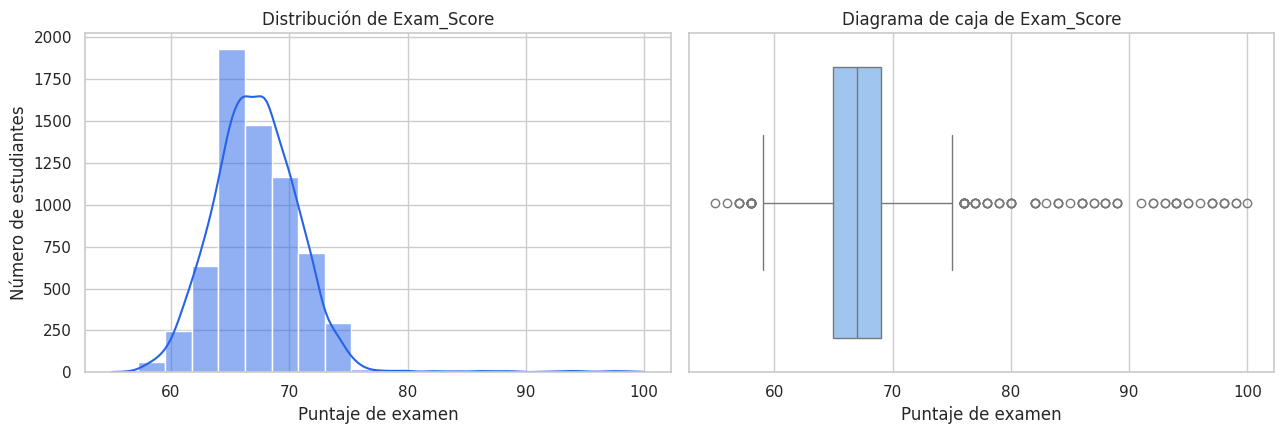

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(
    data=df_clean,
    x="Exam_Score",
    bins=20,
    kde=True,
    color="#2563EB",
    ax=axes[0]
)
axes[0].set_title("Distribución de Exam_Score")
axes[0].set_xlabel("Puntaje de examen")
axes[0].set_ylabel("Número de estudiantes")

sns.boxplot(
    data=df_clean,
    x="Exam_Score",
    color="#93C5FD",
    ax=axes[1]
)
axes[1].set_title("Diagrama de caja de Exam_Score")
axes[1].set_xlabel("Puntaje de examen")

plt.tight_layout()
plt.show()

### Mi interpretación de `Exam_Score`

Observé que la mayor parte de los puntajes se concentra alrededor de la zona media de la distribución. La mediana es cercana a 67 y el 50 % central se encuentra aproximadamente entre 65 y 69 puntos. El histograma muestra una concentración clara y una cola hacia puntajes altos.

El criterio IQR identifica observaciones alejadas de la distribución central. Después de retirar el valor 101, conservé los demás puntajes atípicos porque siguen dentro de la escala de 0 a 100. Estos casos podrían afectar métricas sensibles a errores grandes durante el modelado y deberán revisarse nuevamente en la etapa de evaluación.

## 7. Exploración de variables numéricas

In [11]:
numeric_variables_to_explore = ["Hours_Studied", "Attendance"]

numeric_exploration = df_clean[numeric_variables_to_explore].describe().T

for column in numeric_variables_to_explore:
    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    numeric_exploration.loc[column, "IQR_lower_limit"] = lower_limit
    numeric_exploration.loc[column, "IQR_upper_limit"] = upper_limit
    numeric_exploration.loc[column, "Outlier_count"] = (
        (df_clean[column] < lower_limit) | (df_clean[column] > upper_limit)
    ).sum()

display(numeric_exploration.round(2))

,count,mean,std,min,25%,50%,75%,max,IQR_lower_limit,IQR_upper_limit,Outlier_count
Hours_Studied,6606.0,19.97,5.99,1.0,16.0,20.0,24.0,44.0,4.0,36.0,43.0
Attendance,6606.0,79.97,11.55,60.0,70.0,80.0,90.0,100.0,40.0,120.0,0.0


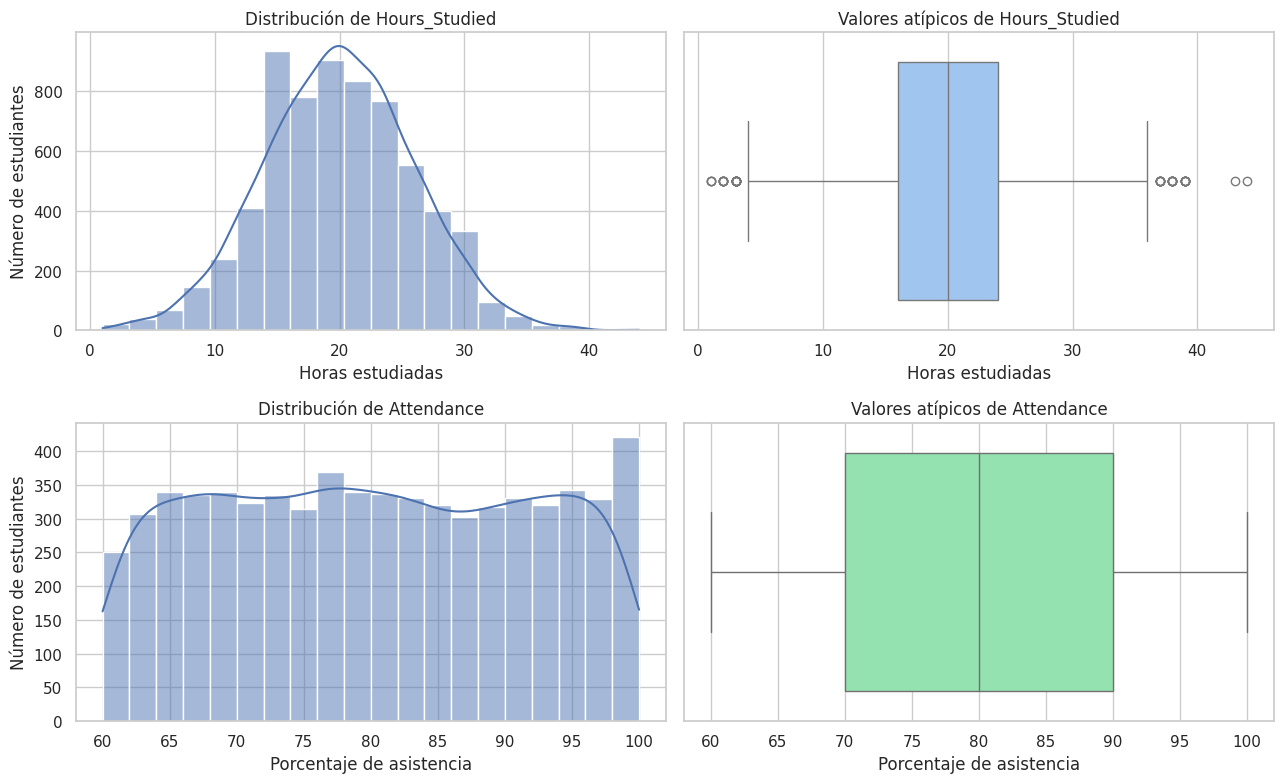

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df_clean["Hours_Studied"], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribución de Hours_Studied")
axes[0, 0].set_xlabel("Horas estudiadas")
axes[0, 0].set_ylabel("Número de estudiantes")

sns.boxplot(x=df_clean["Hours_Studied"], ax=axes[0, 1], color="#93C5FD")
axes[0, 1].set_title("Valores atípicos de Hours_Studied")
axes[0, 1].set_xlabel("Horas estudiadas")

sns.histplot(df_clean["Attendance"], bins=20, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribución de Attendance")
axes[1, 0].set_xlabel("Porcentaje de asistencia")
axes[1, 0].set_ylabel("Número de estudiantes")

sns.boxplot(x=df_clean["Attendance"], ax=axes[1, 1], color="#86EFAC")
axes[1, 1].set_title("Valores atípicos de Attendance")
axes[1, 1].set_xlabel("Porcentaje de asistencia")

plt.tight_layout()
plt.show()

### Mi interpretación de las variables numéricas

En `Hours_Studied` encontré algunos valores altos según el criterio IQR. Decidí conservarlos porque el máximo observado todavía puede representar una carga de estudio semanal posible. En `Attendance` los valores permanecen dentro de 60 a 100 y no aparecen casos fuera del rango lógico de un porcentaje.

Estas variables tienen escalas diferentes: las horas de estudio llegan aproximadamente a la mitad de la escala de asistencia. Por eso aplicaré estandarización antes de utilizarlas en algoritmos sensibles a la magnitud de las variables.

## 8. Exploración de variables categóricas

In [13]:
categorical_variables_to_explore = [
    "Parental_Involvement",
    "Internet_Access"
]

for column in categorical_variables_to_explore:
    frequency_table = (
        df_clean[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="Frecuencia")
    )
    frequency_table["Porcentaje"] = (
        frequency_table["Frecuencia"] / len(df_clean) * 100
    ).round(2)
    print(f"Frecuencias de {column}:")
    display(frequency_table)

Frecuencias de Parental_Involvement:


,Parental_Involvement,Frecuencia,Porcentaje
0,Medium,3362,50.89
1,High,1908,28.88
2,Low,1336,20.22


Frecuencias de Internet_Access:


,Internet_Access,Frecuencia,Porcentaje
0,Yes,6108,92.46
1,No,498,7.54


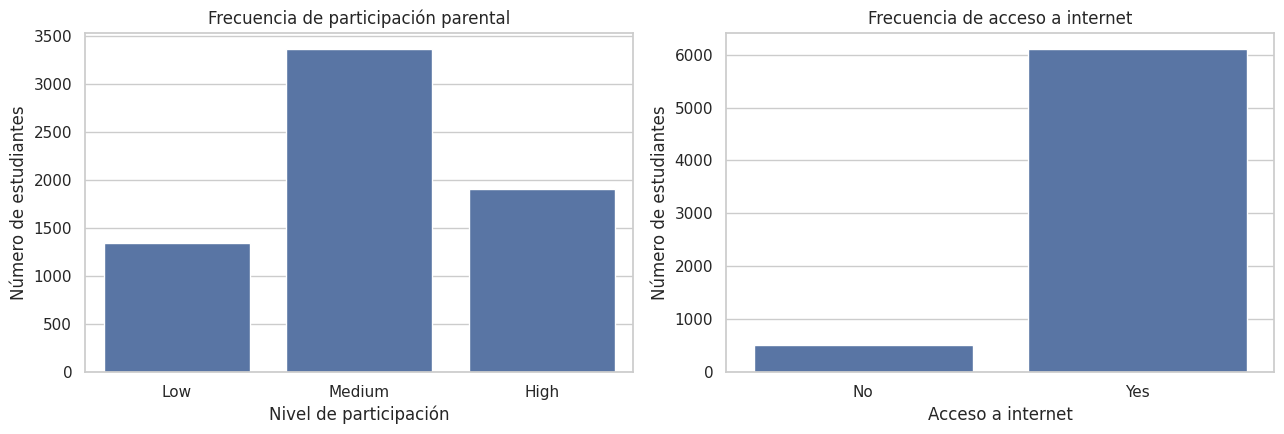

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(
    data=df_clean,
    x="Parental_Involvement",
    order=["Low", "Medium", "High"],
    ax=axes[0]
)
axes[0].set_title("Frecuencia de participación parental")
axes[0].set_xlabel("Nivel de participación")
axes[0].set_ylabel("Número de estudiantes")

sns.countplot(
    data=df_clean,
    x="Internet_Access",
    order=["No", "Yes"],
    ax=axes[1]
)
axes[1].set_title("Frecuencia de acceso a internet")
axes[1].set_xlabel("Acceso a internet")
axes[1].set_ylabel("Número de estudiantes")

plt.tight_layout()
plt.show()

### Mi interpretación de las variables categóricas

`Parental_Involvement` contiene tres niveles con orden lógico: bajo, medio y alto. El nivel medio es el más frecuente, pero las tres categorías tienen una cantidad suficiente de observaciones y no encontré variantes inconsistentes después de estandarizar el texto.

`Internet_Access` es una variable binaria nominal. La categoría `Yes` es mucho más frecuente que `No`, lo cual muestra cierto desbalance, aunque ambas categorías están presentes. Este desbalance deberá considerarse al interpretar cualquier relación posterior con el puntaje.

## 9. Plan reproducible de transformación

Utilicé `ColumnTransformer` para aplicar cada tratamiento según el tipo de variable:

| Grupo | Variables | Transformación | Justificación |
|---|---|---|---|
| Numéricas | Hours_Studied, Attendance, Sleep_Hours, Previous_Scores, Tutoring_Sessions y Physical_Activity | Imputación con mediana y StandardScaler | La mediana es resistente a valores extremos y la estandarización coloca las variables en escalas comparables. |
| Ordinales | Parental_Involvement, Access_to_Resources, Motivation_Level, Family_Income, Teacher_Quality, Peer_Influence, Parental_Education_Level y Distance_from_Home | Imputación con moda y OrdinalEncoder | Estas categorías poseen un orden que debe conservarse. |
| Nominales | Extracurricular_Activities, Internet_Access, School_Type, Learning_Disabilities y Gender | Imputación con moda y One-Hot Encoding | No existe un orden natural; cada categoría se representa mediante una columna independiente. |
| Objetivo | Exam_Score | Se conserva sin escalar | Debe mantener su interpretación original como puntaje. |

La diferencia principal es que una variable **ordinal** sí expresa jerarquía, por ejemplo, bajo < medio < alto. Una variable **nominal** solamente distingue categorías, por ejemplo, escuela pública o privada, sin indicar que una sea mayor que la otra.

En esta actividad ajusto el transformador sobre todo el dataset únicamente para producir el archivo preparado. Cuando entrene un modelo, primero deberé dividir los datos y ajustar estas transformaciones **solo con el conjunto de entrenamiento** para evitar fuga de información.

In [15]:
numeric_features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity"
]

ordinal_features = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality",
    "Peer_Influence",
    "Parental_Education_Level",
    "Distance_from_Home"
]

ordinal_categories = [
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Negative", "Neutral", "Positive"],
    ["High School", "College", "Postgraduate"],
    ["Far", "Moderate", "Near"]
]

nominal_features = [
    "Extracurricular_Activities",
    "Internet_Access",
    "School_Type",
    "Learning_Disabilities",
    "Gender"
]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("ordinal", ordinal_pipeline, ordinal_features),
        ("nominal", nominal_pipeline, nominal_features)
    ],
    verbose_feature_names_out=False
)

feature_columns = numeric_features + ordinal_features + nominal_features
transformed_matrix = preprocessor.fit_transform(df_clean[feature_columns])
transformed_names = preprocessor.get_feature_names_out()

if hasattr(transformed_matrix, "toarray"):
    transformed_matrix = transformed_matrix.toarray()

prepared_df = pd.DataFrame(transformed_matrix, columns=transformed_names)
prepared_df["Exam_Score"] = df_clean["Exam_Score"].to_numpy()

print(f"Dimensiones transformadas: {prepared_df.shape}")
print(f"Valores faltantes después de transformar: {prepared_df.isna().sum().sum()}")
display(prepared_df.head())

Dimensiones transformadas: (6606, 25)
Valores faltantes después de transformar: 0


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,Teacher_Quality,Peer_Influence,Parental_Education_Level,Distance_from_Home,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,School_Type_Private,School_Type_Public,Learning_Disabilities_No,Learning_Disabilities_Yes,Gender_Female,Gender_Male,Exam_Score
0,0.505133,0.348650,-0.019901,-0.143617,-1.214158,0.031414,0.0,2.0,0.0,0.0,1.0,2.0,0.0,2.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,67
1,-0.162650,-1.383650,0.661268,-1.115968,0.412105,1.001129,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,61
2,0.672079,1.561259,-0.019901,1.106548,0.412105,1.001129,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,74
3,1.506808,0.781725,0.661268,1.592723,-0.401027,1.001129,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,71
4,-0.162650,1.041570,-0.701069,-0.699247,1.225236,1.001129,1.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,70


## 10. Comparación antes y después del escalamiento

In [16]:
numeric_before_after = pd.DataFrame({
    "Hours_Studied_original": df_clean["Hours_Studied"].head(8).to_numpy(),
    "Hours_Studied_standardized": prepared_df["Hours_Studied"].head(8).to_numpy(),
    "Attendance_original": df_clean["Attendance"].head(8).to_numpy(),
    "Attendance_standardized": prepared_df["Attendance"].head(8).to_numpy()
})

display(numeric_before_after.round(3))

scaling_summary = pd.DataFrame({
    "Estado": ["Antes", "Después"],
    "Media_Hours_Studied": [
        df_clean["Hours_Studied"].mean(),
        prepared_df["Hours_Studied"].mean()
    ],
    "Desviacion_Hours_Studied": [
        df_clean["Hours_Studied"].std(ddof=0),
        prepared_df["Hours_Studied"].std(ddof=0)
    ],
    "Media_Attendance": [
        df_clean["Attendance"].mean(),
        prepared_df["Attendance"].mean()
    ],
    "Desviacion_Attendance": [
        df_clean["Attendance"].std(ddof=0),
        prepared_df["Attendance"].std(ddof=0)
    ]
})
display(scaling_summary.round(3))

,Hours_Studied_original,Hours_Studied_standardized,Attendance_original,Attendance_standardized
0,23,0.505,84,0.349
1,19,-0.163,64,-1.384
2,24,0.672,98,1.561
3,29,1.507,89,0.782
4,19,-0.163,92,1.042
5,19,-0.163,88,0.695
6,29,1.507,84,0.349
7,25,0.839,78,-0.171


,Estado,Media_Hours_Studied,Desviacion_Hours_Studied,Media_Attendance,Desviacion_Attendance
0,Antes,19.974,5.99,79.975,11.545
1,Después,-0.000,1.00,-0.000,1.000


### Mi interpretación del escalamiento

Después de aplicar `StandardScaler`, las variables quedan con media cercana a 0 y desviación estándar cercana a 1. No cambié el orden de los estudiantes ni la forma relativa de la distribución; únicamente cambié la unidad en la que se expresan los valores.

Esto es importante para algoritmos basados en distancias o penalizaciones, porque una variable con números más grandes podría dominar los cálculos aunque no fuera realmente más importante.

## 11. Comparación antes y después de la codificación

In [17]:
categorical_before_after = pd.concat([
    df_clean[["Parental_Involvement", "School_Type"]].head(8).reset_index(drop=True),
    prepared_df[
        ["Parental_Involvement", "School_Type_Private", "School_Type_Public"]
    ].head(8).reset_index(drop=True)
], axis=1)

categorical_before_after.columns = [
    "Parental_Involvement_original",
    "School_Type_original",
    "Parental_Involvement_ordinal",
    "School_Type_Private_onehot",
    "School_Type_Public_onehot"
]

display(categorical_before_after)

,Parental_Involvement_original,School_Type_original,Parental_Involvement_ordinal,School_Type_Private_onehot,School_Type_Public_onehot
0,Low,Public,0.0,0.0,1.0
1,Low,Public,0.0,0.0,1.0
2,Medium,Public,1.0,0.0,1.0
3,Low,Public,0.0,0.0,1.0
4,Medium,Public,1.0,0.0,1.0
5,Medium,Public,1.0,0.0,1.0
6,Medium,Private,1.0,1.0,0.0
7,Low,Public,0.0,0.0,1.0


### Mi interpretación de la codificación

En `Parental_Involvement` conservé el orden mediante valores 0, 1 y 2 para representar bajo, medio y alto. En cambio, no asigné un número único a `School_Type`, porque hacerlo podría sugerir falsamente que una categoría es mayor que otra. One-Hot Encoding creó una columna binaria para cada categoría.

La codificación cambió la representación de los datos, pero no su significado. También aumentó el número total de columnas porque una variable nominal puede producir varias columnas binarias.

## 12. Comparación del estado inicial y final

In [18]:
final_rows, final_columns = prepared_df.shape
final_missing = int(prepared_df.isna().sum().sum())
final_duplicates = int(prepared_df.duplicated().sum())

state_comparison = pd.DataFrame({
    "Elemento": [
        "Número de registros",
        "Número de variables",
        "Valores faltantes",
        "Registros duplicados",
        "Variables categóricas transformadas",
        "Variables numéricas escaladas"
    ],
    "Estado inicial": [
        initial_rows,
        initial_columns,
        initial_missing,
        initial_duplicates,
        "0",
        "0"
    ],
    "Estado final": [
        final_rows,
        final_columns,
        final_missing,
        final_duplicates,
        f"{len(ordinal_features) + len(nominal_features)} variables",
        f"{len(numeric_features)} variables"
    ]
})

display(state_comparison)

,Elemento,Estado inicial,Estado final
0,Número de registros,6607,6606
1,Número de variables,20,25
2,Valores faltantes,235,0
3,Registros duplicados,0,0
4,Variables categóricas transformadas,0,13 variables
5,Variables numéricas escaladas,0,6 variables


La cantidad de registros disminuyó en uno debido al puntaje 101 que quedó fuera del rango asumido. El número de variables aumentó por One-Hot Encoding. Los valores faltantes quedaron resueltos mediante imputación y el conjunto final contiene solamente valores numéricos.

## 14. Conclusión

En esta actividad realicé un diagnóstico inicial del Student Performance Factors Dataset. Identifiqué 235 valores faltantes distribuidos en `Teacher_Quality`, `Parental_Education_Level` y `Distance_from_Home`. No encontré duplicados, variables constantes, identificadores innecesarios ni columnas numéricas almacenadas como texto. También detecté valores atípicos mediante el criterio IQR y un registro con `Exam_Score = 101`.

Estandaricé los nombres y las categorías, confirmé los tipos numéricos, eliminé duplicados de manera preventiva y retiré el único puntaje fuera del rango de 0 a 100 que asumí para esta actividad. Después utilicé un `ColumnTransformer` para imputar los valores faltantes, escalar seis variables numéricas, codificar ocho variables ordinales y aplicar One-Hot Encoding a cinco variables nominales.

La codificación permitió convertir las categorías en valores utilizables por un algoritmo sin inventar un orden en las variables nominales. El escalamiento colocó las variables numéricas en una escala comparable sin eliminar la relación entre sus observaciones. El archivo final conserva `Exam_Score`, contiene 6,606 registros, no presenta valores faltantes y puede cargarse correctamente desde CSV.

Una limitación importante es que la decisión de considerar 100 como máximo depende del supuesto de que `Exam_Score` es porcentual. Además, un dataset limpio no garantiza que sea representativo ni que sus relaciones sean causales. Antes de entrenar un modelo, mi siguiente paso sería separar los datos en entrenamiento y prueba y volver a ajustar el preprocesamiento únicamente con el conjunto de entrenamiento para evitar fuga de información.